## 1. Setup + SHAP values

In [1]:
# Final model: XGBoost
# Dataset: Diabetes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings("ignore")

import shap

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42

OUTPUT_DIR = os.path.join(os.getcwd(),"..", "outputs", "diabetes", "SHAP")
os.makedirs(OUTPUT_DIR, exist_ok=True)

shap.initjs()

print("All imports successful.")
print(f"SHAP version : {shap.__version__}")
print(f"Output folder: {OUTPUT_DIR}")

All imports successful.
SHAP version : 0.51.0
Output folder: c:\Users\adwet\OneDrive\Documents\Production Project\explainable-disease-risk-prediction\notebooks\..\outputs\diabetes\SHAP


## 2. Load Data & Train Final Random Forest

In [2]:
# Load Diabetes dataset

dia_df = pd.read_csv("../data/diabetes/diabetes_cleaned.csv")

X = dia_df.drop(columns=["Outcome"])
y = dia_df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)
print("Class distribution:")
print(y.value_counts())

Training set: (614, 8)
Testing set : (154, 8)
Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [3]:
# Build XGBoost pipeline — SMOTE inside CV fold to avoid leakage

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 6],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_

print("\nBest params :", xgb_grid.best_params_)
print("Best CV AUC :", round(xgb_grid.best_score_, 4))

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best params : {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Best CV AUC : 0.837


In [4]:
# Test-set performance

y_pred = xgb_best.predict(X_test)
y_prob = xgb_best.predict_proba(X_test)[:, 1]

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test ROC-AUC :", round(roc_auc_score(y_test, y_prob), 4))
print()
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

Test Accuracy: 0.7468
Test ROC-AUC : 0.8233

              precision    recall  f1-score   support

 No Diabetes       0.87      0.72      0.79       100
    Diabetes       0.61      0.80      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.75       154



In [5]:
# Prepare data for SHAP
# XGBoost was trained after scaling, so SHAP should explain scaled test data.

scaler = xgb_best.named_steps["scaler"]
xgb_model = xgb_best.named_steps["classifier"]

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data :", X_test_scaled.shape)

Scaled training data: (614, 8)
Scaled testing data : (154, 8)


In [6]:
# Create SHAP explainer for XGBoost

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values shape:", np.array(shap_values).shape)
print("Expected value:", explainer.expected_value)

SHAP values shape: (154, 8)
Expected value: 0.006163


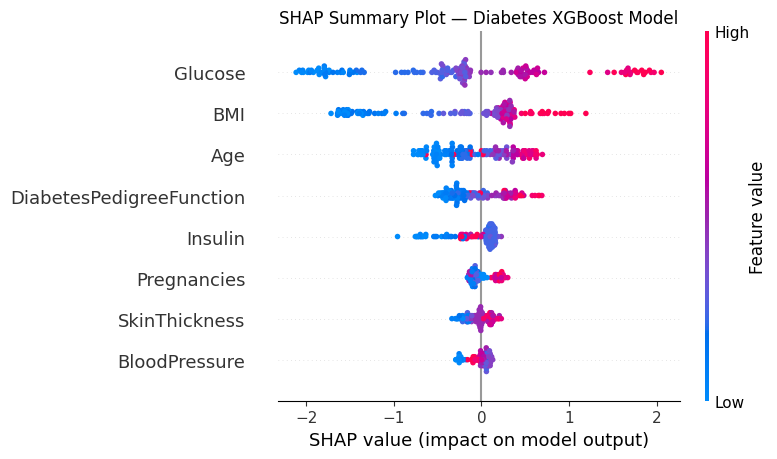

Saved → c:\Users\adwet\OneDrive\Documents\Production Project\explainable-disease-risk-prediction\notebooks\..\outputs\diabetes\SHAP/diabetes_shap_summary_beeswarm.png


In [7]:
# SHAP Summary Plot — Beeswarm

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    show=False
)

plt.title("SHAP Summary Plot — Diabetes XGBoost Model")
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/diabetes_shap_summary_beeswarm.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print(f"Saved → {OUTPUT_DIR}/diabetes_shap_summary_beeswarm.png")

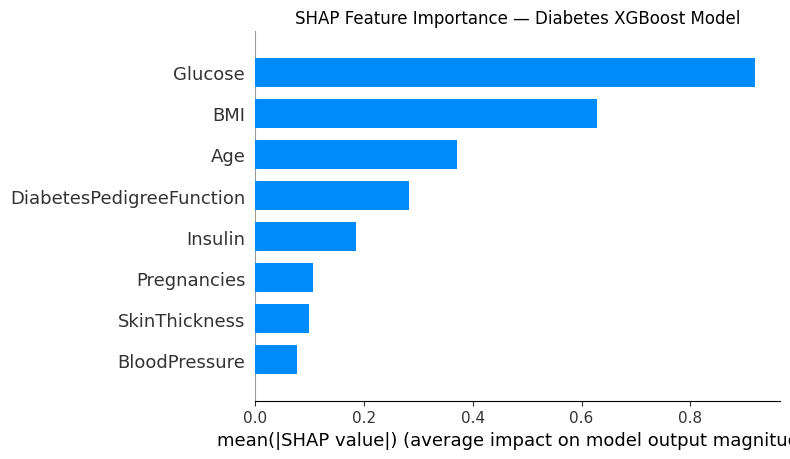

Saved → c:\Users\adwet\OneDrive\Documents\Production Project\explainable-disease-risk-prediction\notebooks\..\outputs\diabetes\SHAP/diabetes_shap_feature_importance_bar.png


In [8]:
# SHAP Summary Plot — Bar Plot

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance — Diabetes XGBoost Model")
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/diabetes_shap_feature_importance_bar.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print(f"Saved → {OUTPUT_DIR}/diabetes_shap_feature_importance_bar.png")

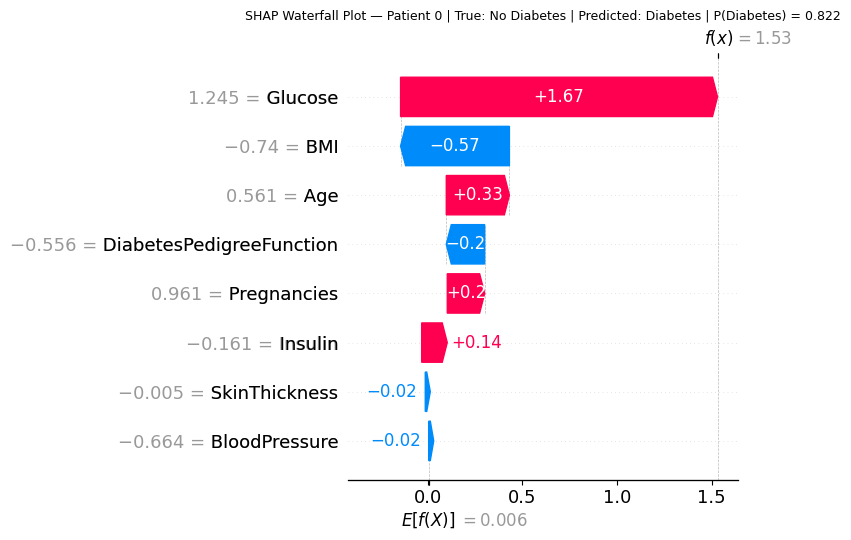

Saved → c:\Users\adwet\OneDrive\Documents\Production Project\explainable-disease-risk-prediction\notebooks\..\outputs\diabetes\SHAP/diabetes_shap_waterfall_patient0.png


In [9]:
# SHAP Waterfall Plot for one patient

patient_idx = 0

true_label = y_test.iloc[patient_idx]
pred_label = y_pred[patient_idx]
pred_prob = y_prob[patient_idx]

explanation = shap.Explanation(
    values=shap_values[patient_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled.iloc[patient_idx],
    feature_names=X_test_scaled.columns
)

plt.figure()
shap.plots.waterfall(
    explanation,
    max_display=12,
    show=False
)

plt.title(
    f"SHAP Waterfall Plot — Patient {patient_idx} | "
    f"True: {'Diabetes' if true_label == 1 else 'No Diabetes'} | "
    f"Predicted: {'Diabetes' if pred_label == 1 else 'No Diabetes'} | "
    f"P(Diabetes) = {pred_prob:.3f}",
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/diabetes_shap_waterfall_patient0.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print(f"Saved → {OUTPUT_DIR}/diabetes_shap_waterfall_patient0.png")

<Figure size 640x480 with 0 Axes>

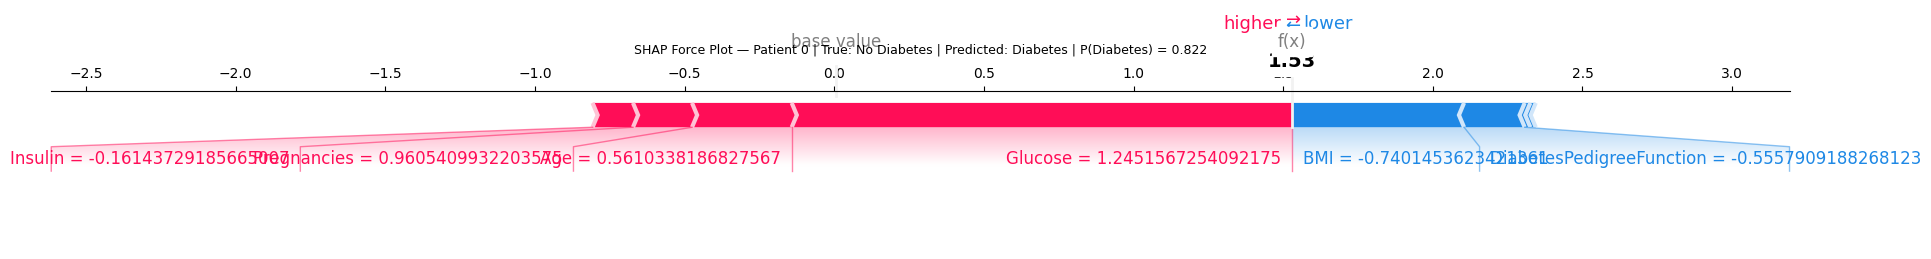

Saved → c:\Users\adwet\OneDrive\Documents\Production Project\explainable-disease-risk-prediction\notebooks\..\outputs\diabetes\SHAP/diabetes_shap_force_plot_patient0.png


In [10]:
# Static SHAP Force Plot for report

plt.figure()

shap.force_plot(
    explainer.expected_value,
    shap_values[patient_idx],
    X_test_scaled.iloc[patient_idx],
    matplotlib=True,
    show=False
)

plt.title(
    f"SHAP Force Plot — Patient {patient_idx} | "
    f"True: {'Diabetes' if true_label == 1 else 'No Diabetes'} | "
    f"Predicted: {'Diabetes' if pred_label == 1 else 'No Diabetes'} | "
    f"P(Diabetes) = {pred_prob:.3f}",
    fontsize=9,
    pad=10
)

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/diabetes_shap_force_plot_patient0.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print(f"Saved → {OUTPUT_DIR}/diabetes_shap_force_plot_patient0.png")

Most important SHAP feature: Glucose


<Figure size 640x480 with 0 Axes>

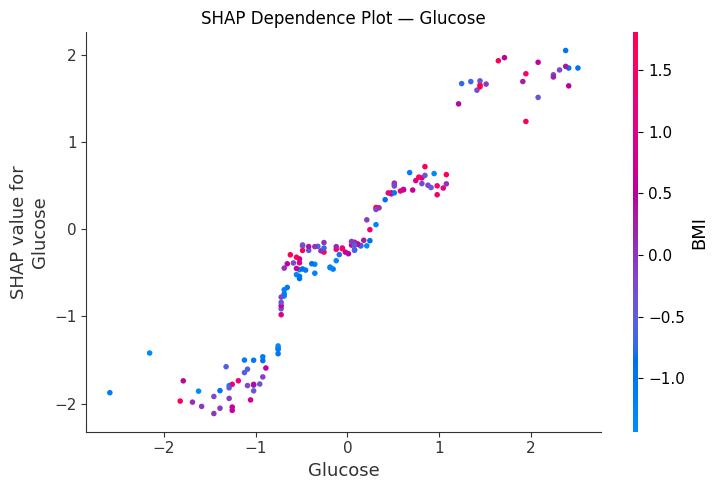

Saved → c:\Users\adwet\OneDrive\Documents\Production Project\explainable-disease-risk-prediction\notebooks\..\outputs\diabetes\SHAP/diabetes_shap_dependence_Glucose.png


In [11]:
# SHAP Dependence Plot for most important feature

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature = X_test_scaled.columns[np.argmax(mean_abs_shap)]

print("Most important SHAP feature:", top_feature)

plt.figure()
shap.dependence_plot(
    top_feature,
    shap_values,
    X_test_scaled,
    show=False
)

plt.title(f"SHAP Dependence Plot — {top_feature}")
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/diabetes_shap_dependence_{top_feature}.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print(f"Saved → {OUTPUT_DIR}/diabetes_shap_dependence_{top_feature}.png")

In [12]:
# Final confirmation

print("=" * 60)
print("DIABETES SHAP EXPLAINABILITY COMPLETED")
print("=" * 60)
print("Final model used: XGBoost")
print(f"All SHAP outputs saved in: {OUTPUT_DIR}")

DIABETES SHAP EXPLAINABILITY COMPLETED
Final model used: XGBoost
All SHAP outputs saved in: c:\Users\adwet\OneDrive\Documents\Production Project\explainable-disease-risk-prediction\notebooks\..\outputs\diabetes\SHAP
